In [79]:
from typing import TypedDict,List
from langgraph.graph import StateGraph, START, END
import random

In [80]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int
    target_number: int


In [81]:
GREET_NODE: str = "greet"
RANDOM_NUM_GEN_NODE: str = "random"

LOOP_EDGE: str = 'loop'
EXIT_EDGE: str = "exit"

MAX_COUNTER: int = 1000


def greeting_node(state: AgentState) -> AgentState:
    """Greeting node which says hi to a person"""
    state['name'] = f"Hi there , {state['name']}. we will start the game"
    state['counter'] = 0
    return state


def random_state(state: AgentState) -> AgentState:
    """Generate number (random) between 0 to 10"""
    state['number'].append(random.randint(0, 10))
    state['counter'] += 1
    return state


def should_continue(state: AgentState) -> str:
    """Function to decide what to do next"""
    if state['target_number'] != state['number'][-1] and state['counter'] < MAX_COUNTER:
        print(f"Enter the loop {state['counter']} ,Current Number : {state['number'][-1]}")
        return LOOP_EDGE
    else:
        print(f"Exit the loop {state['counter']}")
        return EXIT_EDGE


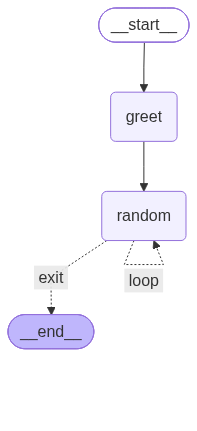

In [82]:

graph = StateGraph(AgentState)
graph.add_node(GREET_NODE, greeting_node)
graph.add_node(RANDOM_NUM_GEN_NODE, random_state)

graph.add_edge(START, GREET_NODE)
graph.add_edge(GREET_NODE, RANDOM_NUM_GEN_NODE)

graph.add_conditional_edges(
    RANDOM_NUM_GEN_NODE, should_continue,
    {
        LOOP_EDGE: RANDOM_NUM_GEN_NODE,
        EXIT_EDGE: END
    }
)
graph.add_edge(RANDOM_NUM_GEN_NODE, END)

bot = graph.compile()
bot

In [83]:
input_state = {
    "name": "Minhaz Uddin",
    "number": [],
    "counter": 0,
    "target_number":5
}

response = bot.invoke(input_state)
response

Enter the loop 1 ,Current Number : 6
Enter the loop 2 ,Current Number : 1
Enter the loop 3 ,Current Number : 7
Enter the loop 4 ,Current Number : 2
Enter the loop 5 ,Current Number : 0
Enter the loop 6 ,Current Number : 0
Enter the loop 7 ,Current Number : 0
Enter the loop 8 ,Current Number : 10
Enter the loop 9 ,Current Number : 2
Enter the loop 10 ,Current Number : 1
Enter the loop 11 ,Current Number : 6
Enter the loop 12 ,Current Number : 6
Enter the loop 13 ,Current Number : 9
Enter the loop 14 ,Current Number : 10
Enter the loop 15 ,Current Number : 8
Exit the loop 16


{'name': 'Hi there , Minhaz Uddin. we will start the game',
 'number': [6, 1, 7, 2, 0, 0, 0, 10, 2, 1, 6, 6, 9, 10, 8, 5],
 'counter': 16,
 'target_number': 5}